# 06. Sparkov Probability Calibration

This notebook evaluates whether the selected Sparkov fraud model produces probabilities that can be interpreted more reliably as fraud risk.

A model can rank fraud well while still producing poorly calibrated probabilities.

For example, among transactions assigned a probability near 0.20, a well-calibrated model should produce an observed fraud rate reasonably close to 20%.

## Main Research Question

> Can probability calibration improve probability quality without changing the underlying fraud-ranking task?

## Methods Compared

1. **Raw probability**
   - the selected LightGBM model's original probability

2. **Platt scaling**
   - fits a logistic calibration model on the separate Calibration period

3. **Isotonic regression**
   - fits a flexible monotonic calibration function on the separate Calibration period

## Split Roles

- **Train** — fit preprocessing and fraud model
- **Calibration** — fit Platt and isotonic calibrators
- **Validation** — compare calibration methods and select one
- **Test** — remains locked

## Core Leakage Rule

The calibrators are fitted using **Calibration labels only**.

Validation labels are used only to compare the fitted calibration methods.

Test labels are not used.

## Important Interpretation

Calibration is different from ranking.

PR-AUC and ROC-AUC measure ranking quality.

Brier Score, Log Loss, reliability curves, ECE, calibration intercept, and calibration slope measure probability quality.

A calibration method does **not** need to increase PR-AUC to be useful.

## 1. Import Libraries and Create Output Folders

This notebook is designed to run independently in Kaggle.

It recreates the same dataset preparation, temporal split, past-only features, and imbalance-strategy selection used earlier.

In [5]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)

from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load and Clean the Sparkov Dataset

Expected Kaggle path:

`/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv`

The same cleaning rules used in the earlier notebooks are applied here.

In [6]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop(
    columns=[
        c for c in df.columns
        if c.lower().startswith("unnamed")
    ],
    errors="ignore"
)

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

df["merchant_clean"] = (
    df["merchant"]
    .astype(str)
    .str.replace(
        r"^fraud_",
        "",
        regex=True
    )
)

df = (
    df.sort_values(
        ["unix_time", "trans_num"]
    )
    .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Shape:", df.shape)
print("Fraud rate:", df["is_fraud"].mean())

Shape: (1296675, 24)
Fraud rate: 0.005788651743883394


## 3. Recreate Current-Transaction Features

The calibration experiment uses the same feature base as the previous notebooks.

Changing the feature set here would mix feature engineering and calibration into the same experiment.

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371 * 2 * np.arcsin(np.sqrt(a))


df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days
    / 365.25
)

df["distance_home_to_merchant_km"] = haversine_km(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

print("Current-transaction features created.")

Current-transaction features created.


## 4. Recreate Leakage-Safe Past-Only Features

This notebook uses the same past-only behavioral feature framework introduced in Notebook 04.

No historical fraud label is used in any feature.

In [8]:
def add_past_only_features(data):
    data = (
        data.sort_values(
            ["unix_time", "trans_num"]
        )
        .reset_index(drop=True)
        .copy()
    )

    card_group = data.groupby(
        "cc_num",
        sort=False
    )

    data["card_tx_count_before"] = (
        card_group.cumcount()
    )

    data["card_has_history"] = (
        data["card_tx_count_before"] > 0
    ).astype("int8")

    data["card_prev_unix_time"] = (
        card_group["unix_time"].shift(1)
    )

    data["card_time_since_prev_hours"] = (
        data["unix_time"]
        - data["card_prev_unix_time"]
    ) / 3600.0

    data["_amt_sq"] = data["amt"] ** 2

    data["_card_amt_sum_before"] = (
        card_group["amt"].cumsum()
        - data["amt"]
    )

    data["_card_amt_sq_sum_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_amt_sq"].cumsum()
        - data["_amt_sq"]
    )

    previous_count = (
        data["card_tx_count_before"]
        .replace(0, np.nan)
    )

    data["card_amt_mean_before"] = (
        data["_card_amt_sum_before"]
        / previous_count
    )

    previous_second_moment = (
        data["_card_amt_sq_sum_before"]
        / previous_count
    )

    previous_variance = (
        previous_second_moment
        - data["card_amt_mean_before"] ** 2
    ).clip(lower=0)

    data["card_amt_std_before"] = (
        np.sqrt(previous_variance)
    )

    data["card_amt_ratio_to_mean"] = (
        data["amt"]
        / data[
            "card_amt_mean_before"
        ].replace(0, np.nan)
    )

    data["card_amt_zscore_before"] = (
        (
            data["amt"]
            - data["card_amt_mean_before"]
        )
        / data[
            "card_amt_std_before"
        ].replace(0, np.nan)
    )

    data["card_merchant_pair_count_before"] = (
        data.groupby(
            ["cc_num", "merchant_clean"],
            sort=False
        ).cumcount()
    )

    data["card_new_merchant"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_merchant_first_for_card"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_merchants_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_merchant_first_for_card"].cumsum()
        - data["_merchant_first_for_card"]
    )

    data["card_category_pair_count_before"] = (
        data.groupby(
            ["cc_num", "category"],
            sort=False
        ).cumcount()
    )

    data["card_new_category"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_category_first_for_card"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_categories_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_category_first_for_card"].cumsum()
        - data["_category_first_for_card"]
    )

    merchant_group = data.groupby(
        "merchant_clean",
        sort=False
    )

    data["merchant_tx_count_before"] = (
        merchant_group.cumcount()
    )

    data["_merchant_amt_sum_before"] = (
        merchant_group["amt"].cumsum()
        - data["amt"]
    )

    merchant_previous_count = (
        data["merchant_tx_count_before"]
        .replace(0, np.nan)
    )

    data["merchant_amt_mean_before"] = (
        data["_merchant_amt_sum_before"]
        / merchant_previous_count
    )

    helper_cols = [
        "_amt_sq",
        "_card_amt_sum_before",
        "_card_amt_sq_sum_before",
        "_merchant_first_for_card",
        "_category_first_for_card",
        "_merchant_amt_sum_before",
    ]

    return data.drop(
        columns=helper_cols
    )


df = add_past_only_features(df)

print("Past-only features created.")

Past-only features created.


## 5. Recreate the Fixed Chronological Split

The project keeps the same temporal design:

- Train: 60%
- Calibration: 15%
- Validation: 10%
- Test: 15%
- 24-hour total purge window around each boundary

The Test period remains locked.

In [9]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

PURGE_HOURS = 24
HALF_PURGE_SECONDS = int(
    (PURGE_HOURS / 2) * 3600
)

n = len(df)

train_boundary_idx = int(
    n * TRAIN_RATIO
)

calibration_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
    )
)

validation_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
        + VALIDATION_RATIO
    )
)

train_boundary = int(
    df.iloc[
        train_boundary_idx
    ]["unix_time"]
)

calibration_boundary = int(
    df.iloc[
        calibration_boundary_idx
    ]["unix_time"]
)

validation_boundary = int(
    df.iloc[
        validation_boundary_idx
    ]["unix_time"]
)

train = df[
    df["unix_time"]
    < (
        train_boundary
        - HALF_PURGE_SECONDS
    )
].copy()

calibration = df[
    (
        df["unix_time"]
        > (
            train_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            calibration_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

validation = df[
    (
        df["unix_time"]
        > (
            calibration_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            validation_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

test = df[
    df["unix_time"]
    > (
        validation_boundary
        + HALF_PURGE_SECONDS
    )
].copy()

assert (
    train["unix_time"].max()
    < calibration["unix_time"].min()
)

assert (
    calibration["unix_time"].max()
    < validation["unix_time"].min()
)

assert (
    validation["unix_time"].max()
    < test["unix_time"].min()
)

print({
    "train": len(train),
    "calibration": len(calibration),
    "validation": len(validation),
    "test": len(test),
})

{'train': 777050, 'calibration': 192249, 'validation': 128128, 'test': 193574}


## 6. Verify Calibration and Validation Class Prevalence

Calibration must preserve natural fraud prevalence because the calibrator needs to learn the relationship between model score and observed outcome under a natural class distribution.

Validation also remains unmodified.

In [10]:
split_class_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train),
        "frauds": int(train["is_fraud"].sum()),
        "fraud_rate": float(train["is_fraud"].mean()),
    },
    {
        "split": "calibration",
        "rows": len(calibration),
        "frauds": int(calibration["is_fraud"].sum()),
        "fraud_rate": float(calibration["is_fraud"].mean()),
    },
    {
        "split": "validation",
        "rows": len(validation),
        "frauds": int(validation["is_fraud"].sum()),
        "fraud_rate": float(validation["is_fraud"].mean()),
    },
    {
        "split": "test",
        "rows": len(test),
        "frauds": int(test["is_fraud"].sum()),
        "fraud_rate": float(test["is_fraud"].mean()),
    },
])

display(split_class_summary)

assert (
    split_class_summary["frauds"] > 0
).all()

,split,rows,frauds,fraud_rate
0,train,777050,4584,0.005899
1,calibration,192249,919,0.004780
2,validation,128128,843,0.006579
3,test,193574,1126,0.005817


## 7. Define the Current + Past-Only Feature Set

Notebook 05 compared imbalance strategies using this feature set.

The calibration experiment keeps the features fixed so calibration is the main changing component.

In [11]:
current_numeric_features = [
    "amt",
    "city_pop",
    "age",
    "distance_home_to_merchant_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

past_only_numeric_features = [
    "card_tx_count_before",
    "card_has_history",
    "card_time_since_prev_hours",
    "card_amt_mean_before",
    "card_amt_std_before",
    "card_amt_ratio_to_mean",
    "card_amt_zscore_before",
    "card_merchant_pair_count_before",
    "card_new_merchant",
    "card_distinct_merchants_before",
    "card_category_pair_count_before",
    "card_new_category",
    "card_distinct_categories_before",
    "merchant_tx_count_before",
    "merchant_amt_mean_before",
]

categorical_features = [
    "category",
    "merchant_clean",
    "state",
    "job",
]

numeric_features = (
    current_numeric_features
    + past_only_numeric_features
)

feature_cols = (
    numeric_features
    + categorical_features
)

TARGET = "is_fraud"

print("Total feature columns:", len(feature_cols))

Total feature columns: 30


## 8. Fit Preprocessing on Natural Train Only

Numerical variables use median imputation.

Categorical variables use most-frequent imputation and ordinal encoding.

The preprocessing transformer is fitted on natural Train only.

Calibration and Validation are transformed using the Train-fitted rules.

In [12]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
])

X_train = train[feature_cols]
y_train = (
    train[TARGET]
    .reset_index(drop=True)
)

X_calibration = calibration[feature_cols]
y_calibration = (
    calibration[TARGET]
    .reset_index(drop=True)
)

X_validation = validation[feature_cols]
y_validation = (
    validation[TARGET]
    .reset_index(drop=True)
)

X_train_encoded = (
    preprocessor.fit_transform(
        X_train
    )
)

X_calibration_encoded = (
    preprocessor.transform(
        X_calibration
    )
)

X_validation_encoded = (
    preprocessor.transform(
        X_validation
    )
)

print(
    "Train shape:",
    X_train_encoded.shape
)

print(
    "Calibration shape:",
    X_calibration_encoded.shape
)

print(
    "Validation shape:",
    X_validation_encoded.shape
)

Train shape: (777050, 30)
Calibration shape: (192249, 30)
Validation shape: (128128, 30)


## 9. Reproduce the Imbalance-Strategy Selection From Notebook 05

Notebook 05 selected the imbalance strategy using Validation PR-AUC.

To keep this notebook independently runnable, we reproduce that selection here.

The three candidates are:

- unweighted LightGBM
- weighted LightGBM
- 5:1 Train-only random undersampling

### Important

This step selects the **underlying fraud model**, not the calibration method.

Calibration methods are fitted only after the underlying model has been selected.

In [13]:
COMMON_PARAMS = dict(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

# Unweighted
unweighted_model = LGBMClassifier(
    **COMMON_PARAMS
)

unweighted_model.fit(
    X_train_encoded,
    y_train
)

unweighted_val_proba = (
    unweighted_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

# Weighted
train_legitimate = int(
    (y_train == 0).sum()
)

train_fraud = int(
    (y_train == 1).sum()
)

scale_pos_weight = (
    train_legitimate
    / train_fraud
)

weighted_model = LGBMClassifier(
    **COMMON_PARAMS,
    scale_pos_weight=scale_pos_weight
)

weighted_model.fit(
    X_train_encoded,
    y_train
)

weighted_val_proba = (
    weighted_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

# Undersampled
UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO = 5

rng = np.random.default_rng(
    SEED
)

fraud_positions = np.where(
    y_train.to_numpy() == 1
)[0]

legitimate_positions = np.where(
    y_train.to_numpy() == 0
)[0]

desired_legitimate_count = min(
    len(legitimate_positions),
    len(fraud_positions)
    * UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO
)

sampled_legitimate_positions = rng.choice(
    legitimate_positions,
    size=desired_legitimate_count,
    replace=False
)

undersample_positions = np.concatenate([
    fraud_positions,
    sampled_legitimate_positions,
])

rng.shuffle(
    undersample_positions
)

undersampled_model = LGBMClassifier(
    **COMMON_PARAMS
)

undersampled_model.fit(
    X_train_encoded[
        undersample_positions
    ],
    y_train.iloc[
        undersample_positions
    ]
)

undersampled_val_proba = (
    undersampled_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

imbalance_selection = pd.DataFrame([
    {
        "strategy": "Unweighted LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                unweighted_val_proba
            )
        ),
    },
    {
        "strategy": "Weighted LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                weighted_val_proba
            )
        ),
    },
    {
        "strategy": "Undersampled LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                undersampled_val_proba
            )
        ),
    },
]).sort_values(
    "validation_pr_auc",
    ascending=False
).reset_index(drop=True)

display(
    imbalance_selection
)

selected_strategy = (
    imbalance_selection
    .iloc[0]["strategy"]
)

print(
    "Selected underlying model:",
    selected_strategy
)

,strategy,validation_pr_auc
0,Unweighted LightGBM,0.928586
1,Undersampled LightGBM,0.923141
2,Weighted LightGBM,0.905961


Selected underlying model: Unweighted LightGBM


## 10. Generate Raw Scores for Calibration and Validation

After selecting the underlying fraud model, we use that same model to generate:

- Calibration raw probabilities
- Validation raw probabilities

The Calibration raw probabilities are used to fit Platt and isotonic calibration functions.

In [14]:
if selected_strategy == "Unweighted LightGBM":
    selected_model = unweighted_model

elif selected_strategy == "Weighted LightGBM":
    selected_model = weighted_model

elif selected_strategy == "Undersampled LightGBM":
    selected_model = undersampled_model

else:
    raise ValueError(
        "Unexpected selected strategy."
    )

calibration_raw_proba = (
    selected_model.predict_proba(
        X_calibration_encoded
    )[:, 1]
)

validation_raw_proba = (
    selected_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

print(
    "Mean Calibration raw probability:",
    calibration_raw_proba.mean()
)

print(
    "Calibration fraud rate:",
    y_calibration.mean()
)

print(
    "Mean Validation raw probability:",
    validation_raw_proba.mean()
)

print(
    "Validation fraud rate:",
    y_validation.mean()
)

Mean Calibration raw probability: 0.0037017492170939395
Calibration fraud rate: 0.00478025893502697
Mean Validation raw probability: 0.005123718854188338
Validation fraud rate: 0.006579358141858142


## 11. Fit Platt Scaling on the Calibration Period

Platt scaling fits a logistic relationship between the model score and the observed outcome.

For numerical stability, we first convert the raw probability \(p\) to a logit:

\[
\log\left(\frac{p}{1-p}\right)
\]

The logistic calibration model is then fitted using:

- Calibration logits
- Calibration fraud labels

Validation labels are not used to fit the Platt model.

In [15]:
def probability_to_logit(
    probability,
    eps=1e-8
):
    p = np.clip(
        np.asarray(probability),
        eps,
        1 - eps
    )

    return np.log(
        p / (1 - p)
    )


calibration_raw_logit = (
    probability_to_logit(
        calibration_raw_proba
    )
    .reshape(-1, 1)
)

validation_raw_logit = (
    probability_to_logit(
        validation_raw_proba
    )
    .reshape(-1, 1)
)

platt_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

platt_model.fit(
    calibration_raw_logit,
    y_calibration
)

validation_platt_proba = (
    platt_model.predict_proba(
        validation_raw_logit
    )[:, 1]
)

print("Platt scaling fitted on Calibration.")

Platt scaling fitted on Calibration.


## 12. Fit Isotonic Regression on the Calibration Period

Isotonic regression learns a flexible monotonic mapping from raw model probability to calibrated probability.

Advantages:

- more flexible than Platt scaling

Risks:

- can overfit when calibration data are limited
- may create probability plateaus or ties

The Sparkov Calibration period is much larger than many real fraud datasets, but Validation is still used to determine whether isotonic calibration actually improves probability quality.

In [16]:
isotonic_model = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic_model.fit(
    calibration_raw_proba,
    y_calibration
)

validation_isotonic_proba = (
    isotonic_model.predict(
        validation_raw_proba
    )
)

print(
    "Isotonic regression fitted on Calibration."
)

Isotonic regression fitted on Calibration.


## 13. Define Calibration Metrics

We evaluate each probability version using:

### Brier Score

Mean squared error between probability and binary outcome.

Lower is better.

### Log Loss

Strongly penalizes confident wrong predictions.

Lower is better.

### Expected Calibration Error (ECE)

Compares average predicted probability with observed fraud rate across probability bins.

Lower is better.

ECE depends on the binning scheme, so it should be treated as a descriptive calibration statistic rather than an absolute truth.

### Calibration Intercept and Slope

We fit a diagnostic logistic regression:

`outcome ~ logit(predicted probability)`

Ideal values are approximately:

- intercept = 0
- slope = 1

### Ranking Metrics

PR-AUC and ROC-AUC are retained so we can verify that calibration is not being confused with ranking quality.

In [17]:
def expected_calibration_error(
    y_true,
    proba,
    n_bins=10
):
    y = np.asarray(y_true)
    p = np.asarray(proba)

    table = pd.DataFrame({
        "y": y,
        "p": p,
    })

    table["bin"] = pd.qcut(
        table["p"],
        q=n_bins,
        duplicates="drop"
    )

    grouped = (
        table.groupby(
            "bin",
            observed=True
        )
        .agg(
            count=("y", "size"),
            mean_probability=("p", "mean"),
            observed_rate=("y", "mean"),
        )
        .reset_index()
    )

    grouped["weight"] = (
        grouped["count"]
        / len(table)
    )

    grouped["absolute_gap"] = (
        grouped["mean_probability"]
        - grouped["observed_rate"]
    ).abs()

    ece = (
        grouped["weight"]
        * grouped["absolute_gap"]
    ).sum()

    return float(ece)


def calibration_intercept_slope(
    y_true,
    proba
):
    logit_p = (
        probability_to_logit(
            proba
        )
        .reshape(-1, 1)
    )

    diagnostic = LogisticRegression(
        solver="lbfgs",
        C=1e6,
        max_iter=1000,
        random_state=SEED
    )

    diagnostic.fit(
        logit_p,
        y_true
    )

    intercept = float(
        diagnostic.intercept_[0]
    )

    slope = float(
        diagnostic.coef_[0, 0]
    )

    return intercept, slope


def evaluate_calibration(
    method_name,
    y_true,
    proba
):
    intercept, slope = (
        calibration_intercept_slope(
            y_true,
            proba
        )
    )

    return {
        "method": method_name,
        "pr_auc": average_precision_score(
            y_true,
            proba
        ),
        "roc_auc": roc_auc_score(
            y_true,
            proba
        ),
        "brier": brier_score_loss(
            y_true,
            proba
        ),
        "log_loss": log_loss(
            y_true,
            np.clip(
                proba,
                1e-8,
                1 - 1e-8
            )
        ),
        "ece_10_quantile_bins": (
            expected_calibration_error(
                y_true,
                proba,
                n_bins=10
            )
        ),
        "mean_probability": float(
            np.mean(proba)
        ),
        "observed_fraud_rate": float(
            np.mean(y_true)
        ),
        "calibration_intercept": (
            intercept
        ),
        "calibration_slope": (
            slope
        ),
    }

## 14. Compare Raw, Platt, and Isotonic Probabilities on Validation

The three probability versions are evaluated on the same Validation transactions.

The calibrators themselves were fitted only on Calibration.

In [18]:
calibration_metrics = pd.DataFrame([
    evaluate_calibration(
        "Raw",
        y_validation,
        validation_raw_proba
    ),
    evaluate_calibration(
        "Platt",
        y_validation,
        validation_platt_proba
    ),
    evaluate_calibration(
        "Isotonic",
        y_validation,
        validation_isotonic_proba
    ),
])

calibration_metrics = (
    calibration_metrics
    .sort_values(
        ["brier", "log_loss"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

display(
    calibration_metrics
)

,method,pr_auc,roc_auc,brier,log_loss,ece_10_quantile_bins,mean_probability,observed_fraud_rate,calibration_intercept,calibration_slope
0,Isotonic,0.922456,0.997534,0.001310,0.005460,0.000390,0.006190,0.006579,0.224226,0.950003
1,Platt,0.928586,0.998061,0.001317,0.005457,0.000461,0.006199,0.006579,0.362450,1.004457
2,Raw,0.928586,0.998061,0.001521,0.006812,0.001472,0.005124,0.006579,1.799486,1.008075


## 15. Select the Calibration Method

The primary calibration-selection metric is **Validation Brier Score**.

Log Loss is used as a secondary tie-breaker.

The selected method can be:

- Raw
- Platt
- Isotonic

Choosing Raw is valid if neither fitted calibrator improves Validation probability quality.

In [19]:
selected_calibration_method = (
    calibration_metrics
    .iloc[0]["method"]
)

print(
    "Selected calibration method:",
    selected_calibration_method
)

print(
    "Selection rule: lowest Validation Brier Score, "
    "then lowest Log Loss."
)

Selected calibration method: Isotonic
Selection rule: lowest Validation Brier Score, then lowest Log Loss.


## 16. Reliability Curves

A reliability curve compares:

- mean predicted probability in each bin
- observed fraud rate in that bin

Perfect calibration would lie on the 45-degree reference line.

Because fraud is rare, we use **quantile bins** so bins contain roughly similar numbers of observations.

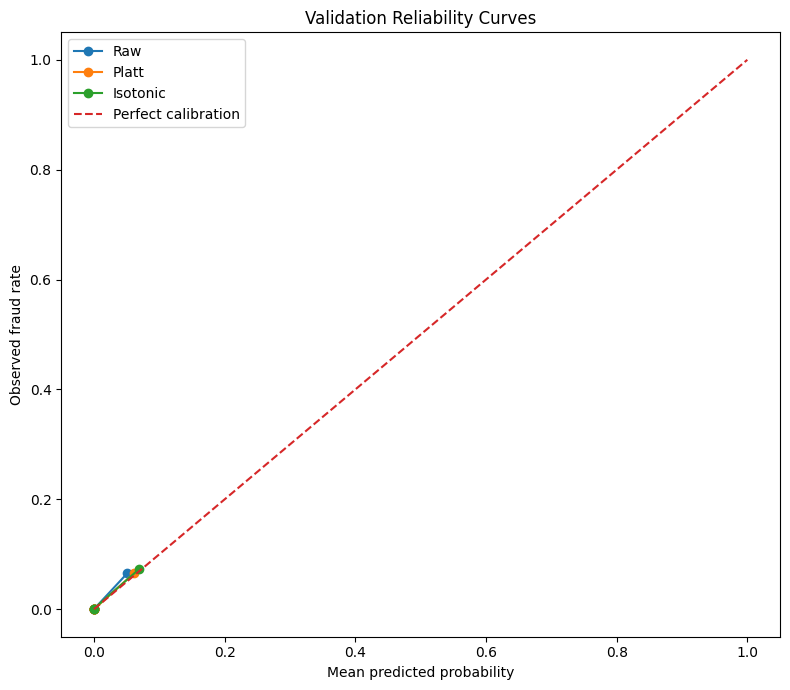

In [20]:
plt.figure(
    figsize=(8, 7)
)

for name, proba in [
    (
        "Raw",
        validation_raw_proba
    ),
    (
        "Platt",
        validation_platt_proba
    ),
    (
        "Isotonic",
        validation_isotonic_proba
    ),
]:
    observed_rate, mean_predicted = (
        calibration_curve(
            y_validation,
            proba,
            n_bins=10,
            strategy="quantile"
        )
    )

    plt.plot(
        mean_predicted,
        observed_rate,
        marker="o",
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel(
    "Mean predicted probability"
)

plt.ylabel(
    "Observed fraud rate"
)

plt.title(
    "Validation Reliability Curves"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "calibration_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 17. Brier Score Comparison

Lower Brier Score indicates better overall probability accuracy.

This figure directly visualizes the primary calibration-selection criterion.

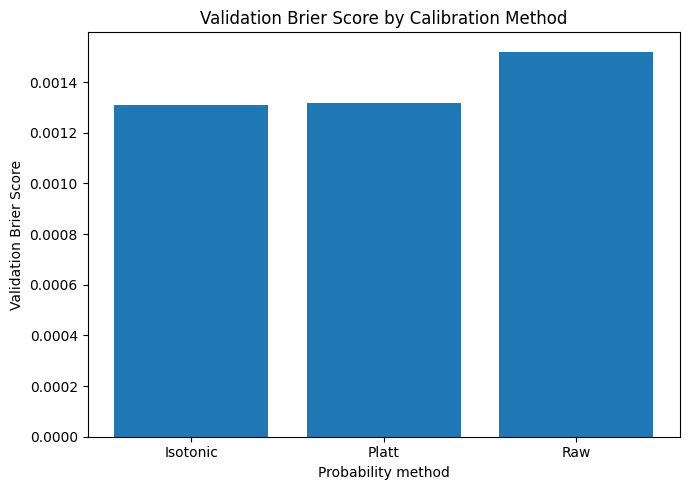

In [21]:
brier_plot = (
    calibration_metrics[
        ["method", "brier"]
    ]
    .sort_values(
        "brier",
        ascending=True
    )
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    brier_plot["method"],
    brier_plot["brier"]
)

plt.xlabel(
    "Probability method"
)

plt.ylabel(
    "Validation Brier Score"
)

plt.title(
    "Validation Brier Score by Calibration Method"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "calibration_brier_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 18. Mean Predicted Probability vs Observed Fraud Rate

A simple calibration sanity check compares:

- average predicted probability
- actual Validation fraud prevalence

This does not replace the reliability curve, but it provides an intuitive global summary.

In [22]:
mean_probability_comparison = (
    calibration_metrics[
        [
            "method",
            "mean_probability",
            "observed_fraud_rate",
        ]
    ]
    .copy()
)

display(
    mean_probability_comparison
)

,method,mean_probability,observed_fraud_rate
0,Isotonic,0.006190,0.006579
1,Platt,0.006199,0.006579
2,Raw,0.005124,0.006579


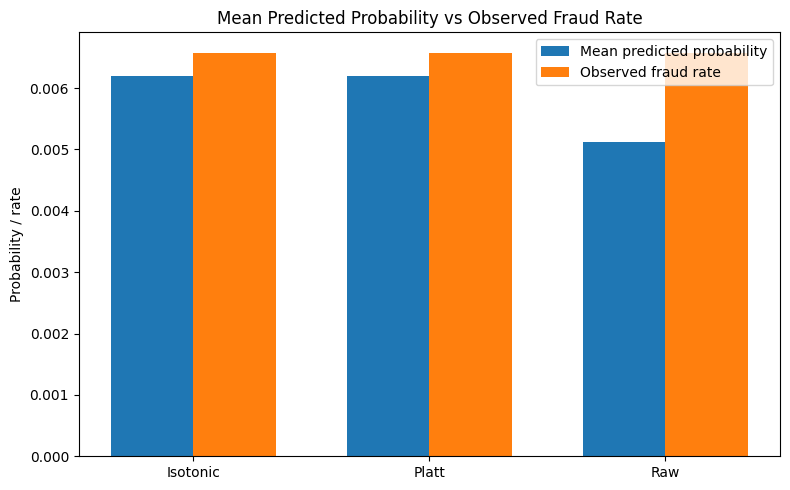

In [23]:
plot_positions = np.arange(
    len(mean_probability_comparison)
)

bar_width = 0.35

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    plot_positions - bar_width / 2,
    mean_probability_comparison[
        "mean_probability"
    ],
    width=bar_width,
    label="Mean predicted probability"
)

plt.bar(
    plot_positions + bar_width / 2,
    mean_probability_comparison[
        "observed_fraud_rate"
    ],
    width=bar_width,
    label="Observed fraud rate"
)

plt.xticks(
    plot_positions,
    mean_probability_comparison[
        "method"
    ]
)

plt.ylabel(
    "Probability / rate"
)

plt.title(
    "Mean Predicted Probability vs Observed Fraud Rate"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "calibration_mean_probability_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 19. Build Calibration Bin Tables

We save the underlying quantile-bin statistics used for descriptive calibration analysis.

For each method and bin, the table contains:

- count
- mean predicted probability
- observed fraud rate
- absolute calibration gap

In [24]:
def build_calibration_bin_table(
    method_name,
    y_true,
    proba,
    n_bins=10
):
    table = pd.DataFrame({
        "y": np.asarray(y_true),
        "probability": np.asarray(proba),
    })

    table["bin"] = pd.qcut(
        table["probability"],
        q=n_bins,
        duplicates="drop"
    )

    grouped = (
        table.groupby(
            "bin",
            observed=True
        )
        .agg(
            count=(
                "y",
                "size"
            ),
            mean_probability=(
                "probability",
                "mean"
            ),
            observed_fraud_rate=(
                "y",
                "mean"
            ),
        )
        .reset_index(drop=True)
    )

    grouped[
        "absolute_gap"
    ] = (
        grouped[
            "mean_probability"
        ]
        - grouped[
            "observed_fraud_rate"
        ]
    ).abs()

    grouped.insert(
        0,
        "bin_number",
        np.arange(
            1,
            len(grouped) + 1
        )
    )

    grouped.insert(
        0,
        "method",
        method_name
    )

    return grouped


calibration_bins = pd.concat([
    build_calibration_bin_table(
        "Raw",
        y_validation,
        validation_raw_proba
    ),
    build_calibration_bin_table(
        "Platt",
        y_validation,
        validation_platt_proba
    ),
    build_calibration_bin_table(
        "Isotonic",
        y_validation,
        validation_isotonic_proba
    ),
], ignore_index=True)

display(
    calibration_bins
)

,method,bin_number,count,mean_probability,observed_fraud_rate,absolute_gap
0,Raw,1,12813,0.000001,0.000000,0.000001
1,Raw,2,12813,0.000002,0.000000,0.000002
2,Raw,3,12813,0.000003,0.000000,0.000003
3,Raw,4,12812,0.000005,0.000000,0.000005
4,Raw,5,12813,0.000008,0.000000,0.000008
5,Raw,6,12813,0.000012,0.000000,0.000012
6,Raw,7,12812,0.000019,0.000000,0.000019
7,Raw,8,12813,0.000033,0.000000,0.000033
8,Raw,9,12813,0.000075,0.000234,0.000159
9,Raw,10,12813,0.051078,0.065558,0.014480


## 20. Save Validation Probabilities

Saving all three probability versions makes later cost-sensitive analysis auditable.

The final selected method is recorded, but no Test probability is generated in this notebook.

In [25]:
validation_predictions = validation[
    [
        "trans_num",
        "trans_date_trans_time",
        "cc_num",
        "merchant_clean",
        "is_fraud",
        "amt",
    ]
].copy()

validation_predictions[
    "raw_probability"
] = validation_raw_proba

validation_predictions[
    "platt_probability"
] = validation_platt_proba

validation_predictions[
    "isotonic_probability"
] = validation_isotonic_proba

if selected_calibration_method == "Raw":
    validation_predictions[
        "selected_probability"
    ] = validation_raw_proba

elif selected_calibration_method == "Platt":
    validation_predictions[
        "selected_probability"
    ] = validation_platt_proba

elif selected_calibration_method == "Isotonic":
    validation_predictions[
        "selected_probability"
    ] = validation_isotonic_proba

else:
    raise ValueError(
        "Unexpected calibration method."
    )

display(
    validation_predictions.head()
)

,trans_num,trans_date_trans_time,cc_num,merchant_clean,is_fraud,amt,raw_probability,platt_probability,isotonic_probability,selected_probability
973144,4b76605c3b0d1af2eb0c4d65471a8507,2020-01-29 03:06:41,30234966027947,Hamill-Daugherty,0,64.480000,0.000001,0.000006,0.000000,0.000000
973145,4bf9edc93a30609997e20b51463f235f,2020-01-29 03:08:10,30044330818990,Herzog Ltd,0,105.470000,0.000029,0.000117,0.000000,0.000000
973146,0f954e9f95faf5c8c2fee730fd15f33c,2020-01-29 03:09:14,4464457352619,"Christiansen, Goyette and Schamberger",0,78.150000,0.000002,0.000006,0.000000,0.000000
973147,77ae0fef10fe571fd75ce0bceac1cd68,2020-01-29 03:09:50,377993105397617,Friesen-Stamm,0,64.900000,0.000007,0.000029,0.000000,0.000000
973148,8b60b26dee5e2e4a7d212b02ace322c5,2020-01-29 03:10:44,4169388510116,Prohaska-Murray,0,60.890000,0.000003,0.000014,0.000000,0.000000


## 21. Save Calibration Selection Configuration

We save:

- selected underlying imbalance strategy
- selected calibration method
- selection criterion
- calibration/validation row counts
- observed fraud prevalence

In [26]:
calibration_configuration = pd.DataFrame([
    {
        "setting": (
            "selected_underlying_model"
        ),
        "value": selected_strategy,
    },
    {
        "setting": (
            "selected_calibration_method"
        ),
        "value": selected_calibration_method,
    },
    {
        "setting": (
            "calibration_selection_primary_metric"
        ),
        "value": "Validation Brier Score",
    },
    {
        "setting": (
            "calibration_selection_secondary_metric"
        ),
        "value": "Validation Log Loss",
    },
    {
        "setting": (
            "calibration_rows"
        ),
        "value": len(calibration),
    },
    {
        "setting": (
            "calibration_fraud_rate"
        ),
        "value": float(
            y_calibration.mean()
        ),
    },
    {
        "setting": (
            "validation_rows"
        ),
        "value": len(validation),
    },
    {
        "setting": (
            "validation_fraud_rate"
        ),
        "value": float(
            y_validation.mean()
        ),
    },
])

display(
    calibration_configuration
)

,setting,value
0,selected_underlying_model,Unweighted LightGBM
1,selected_calibration_method,Isotonic
2,calibration_selection_primary_metric,Validation Brier Score
3,calibration_selection_secondary_metric,Validation Log Loss
4,calibration_rows,192249
5,calibration_fraud_rate,0.004780
6,validation_rows,128128
7,validation_fraud_rate,0.006579


## 22. Save Results

### Results

- `calibration_metrics.csv`
- `calibration_bin_summary.csv`
- `calibration_validation_predictions.csv`
- `calibration_configuration.csv`
- `calibration_imbalance_selection_check.csv`
- `calibration_split_class_summary.csv`

### Figures

- `calibration_curve.png`
- `calibration_brier_comparison.png`
- `calibration_mean_probability_comparison.png`

In [27]:
calibration_metrics.to_csv(
    "/kaggle/working/results/"
    "calibration_metrics.csv",
    index=False
)

calibration_bins.to_csv(
    "/kaggle/working/results/"
    "calibration_bin_summary.csv",
    index=False
)

validation_predictions.to_csv(
    "/kaggle/working/results/"
    "calibration_validation_predictions.csv",
    index=False
)

calibration_configuration.to_csv(
    "/kaggle/working/results/"
    "calibration_configuration.csv",
    index=False
)

imbalance_selection.to_csv(
    "/kaggle/working/results/"
    "calibration_imbalance_selection_check.csv",
    index=False
)

split_class_summary.to_csv(
    "/kaggle/working/results/"
    "calibration_split_class_summary.csv",
    index=False
)

print("Results:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/results"
    )
):
    print("-", filename)

print("\nFigures:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/figures"
    )
):
    print("-", filename)

Results:
- calibration_bin_summary.csv
- calibration_configuration.csv
- calibration_imbalance_selection_check.csv
- calibration_metrics.csv
- calibration_split_class_summary.csv
- calibration_validation_predictions.csv

Figures:
- calibration_brier_comparison.png
- calibration_curve.png
- calibration_mean_probability_comparison.png


## 23. How to Interpret the Results

### If Platt scaling is selected

A smooth logistic correction improved probability quality on Validation.

This is often a useful choice when the raw score is systematically too high or too low.

### If isotonic regression is selected

A more flexible monotonic mapping improved Validation calibration.

Because isotonic is more flexible, its Validation performance is especially important for guarding against overfitting.

### If Raw is selected

The original model probabilities were already at least as good under the chosen Validation calibration metrics.

No calibration method should be forced simply because calibration was attempted.

### PR-AUC

PR-AUC may remain nearly unchanged after calibration.

That is expected because calibration is primarily about the meaning of the probability scale, not the ranking of transactions.

Isotonic regression may create ties, so very small ranking-metric changes can occur.

## 24. Why Calibration Matters for the Next Stage

The next notebook uses probability in cost-sensitive decision rules.

For example, a policy may compare:

- expected prevented fraud loss
- alert-review cost
- customer-friction cost

Those calculations are much more meaningful when the input probability is reasonably calibrated.

A high PR-AUC alone is not enough for probability-based economic decisioning.

## 25. Leakage and Methodology Notes

### Train

Used to fit preprocessing and the fraud model.

### Calibration

Used to fit Platt and isotonic calibrators.

Calibration retains its natural fraud prevalence.

### Validation

Used to compare Raw, Platt, and Isotonic probabilities.

Validation is not used to fit the calibrators.

### Test

Remains untouched.

### No resampling of Calibration

Calibration data must preserve natural prevalence. Resampling Calibration would distort the relationship between predicted probability and observed event rate.

### No final threshold selection here

This notebook selects a probability-calibration method, not an operating threshold.

Threshold and cost-policy selection happen later.

## 26. Limitations

### Synthetic dataset

Sparkov is synthetic, so probability calibration describes the simulator's probability structure rather than a real bank's true default or fraud process.

### Calibration stability

A calibration method can change as prevalence or behavior drifts over time.

A calibrator that works today is not guaranteed to stay calibrated indefinitely.

### ECE depends on bins

ECE changes with the number and definition of bins.

It is included as a supporting diagnostic, not the sole selection rule.

### Isotonic flexibility

Isotonic regression can overfit smaller calibration samples and can create tied probabilities.

### Development reuse of Validation

Validation has already been used for model-development choices in previous notebooks.

That is acceptable within this project's development design, but it reinforces why the final Test period must remain untouched until the full pipeline is frozen.

## Conclusion

This notebook evaluated three probability versions:

1. Raw LightGBM probability
2. Platt-scaled probability
3. Isotonic-calibrated probability

The workflow:

1. recreated the fixed temporal split
2. recreated the current + past-only feature set
3. reproduced the imbalance-strategy selection using Validation PR-AUC
4. generated raw scores for Calibration and Validation
5. fitted Platt scaling on Calibration
6. fitted isotonic regression on Calibration
7. compared calibration quality on Validation
8. selected a calibration method using Validation Brier Score and Log Loss
9. saved probability, reliability, and calibration diagnostics
10. kept the Test period untouched

## Next Notebook

`07_sparkov_cost_decision.ipynb`

The next notebook will use the selected calibrated probability to compare decision rules such as:

- fixed threshold 0.5
- F1-oriented threshold
- proxy-cost-minimizing threshold
- positive expected-benefit decisions

All threshold and cost-policy choices will be made on Validation only.